Identified model:
dN/dt = (-0.2335)*1 + (2.9887)*N + (-5.2915)*N^2 + (2.5598)*N^3

Recovered coefficients:
   1: -0.233501
   N:  2.988718
 N^2: -5.291469
 N^3:  2.559777

True coefficients:
   1:  0.000000
   N:  1.000000
 N^2: -1.000000
 N^3:  0.000000

Derivative-fit MSE: 4.408290e-02


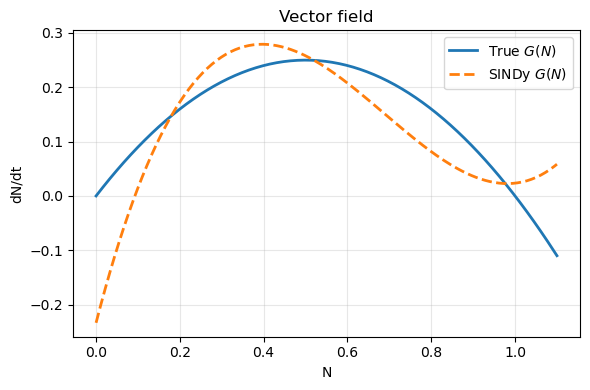

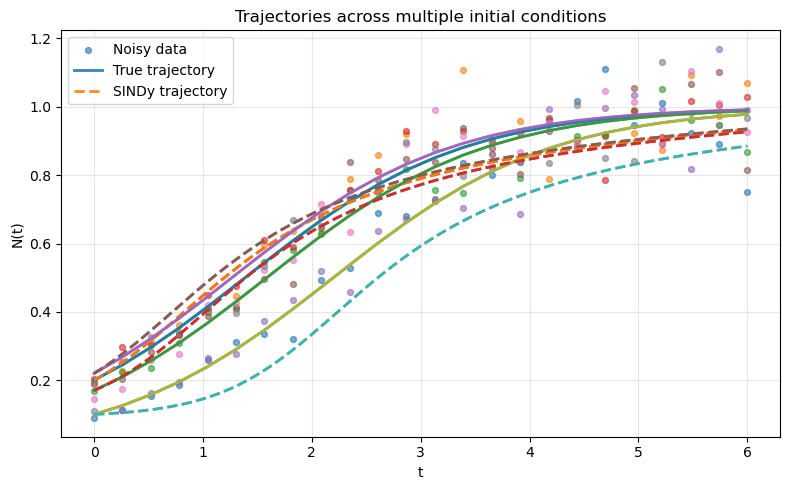

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.10, 0.20, 0.17, 0.22, 0.10, 0.20, 0.17, 0.22]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**1

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**1


# ============================================================
# 3. SINDy utilities
# ============================================================
def build_library(x, poly_order=3, include_constant=True):
    """
    x: [n_samples, 1]
    returns Theta: [n_samples, n_features], feature_names
    """
    feats = []
    names = []

    if include_constant:
        feats.append(torch.ones_like(x))
        names.append("1")

    for p in range(1, poly_order + 1):
        feats.append(x ** p)
        names.append(f"N^{p}" if p > 1 else "N")

    Theta = torch.cat(feats, dim=1)
    return Theta, names


def estimate_time_derivative(y, t):
    """
    Central differences for interior, one-sided for endpoints.
    y: [T, 1]
    t: [T, 1]
    returns dydt: [T, 1]
    """
    dydt = torch.zeros_like(y)
    t = t.squeeze(-1)

    # forward difference
    dydt[0] = (y[1] - y[0]) / (t[1] - t[0])

    # central difference
    for i in range(1, len(t) - 1):
        dydt[i] = (y[i + 1] - y[i - 1]) / (t[i + 1] - t[i - 1])

    # backward difference
    dydt[-1] = (y[-1] - y[-2]) / (t[-1] - t[-2])

    return dydt


def stlsq(Theta, dXdt, lam=0.05, n_iter=10):
    """
    Sequential Thresholded Least Squares (single state variable).

    Theta: [n_samples, n_features]
    dXdt:  [n_samples, 1]
    returns Xi: [n_features, 1]
    """
    # initial least-squares fit
    Xi = torch.linalg.lstsq(Theta, dXdt).solution

    for _ in range(n_iter):
        small = torch.abs(Xi) < lam
        Xi[small] = 0.0

        big_idx = (~small.squeeze(-1)).nonzero(as_tuple=True)[0]
        if len(big_idx) == 0:
            break

        Xi_restricted = torch.linalg.lstsq(Theta[:, big_idx], dXdt).solution
        Xi[:] = 0.0
        Xi[big_idx] = Xi_restricted

    return Xi


def sindy_rhs_from_xi(x, Xi, poly_order=3, include_constant=True):
    Theta, _ = build_library(x, poly_order=poly_order, include_constant=include_constant)
    return Theta @ Xi


def print_sindy_equation(Xi, feature_names, precision=4):
    terms = []
    for coef, name in zip(Xi.squeeze(-1).cpu().numpy(), feature_names):
        if abs(coef) > 1e-12:
            terms.append(f"({coef:.{precision}f})*{name}")
    eqn = " + ".join(terms) if terms else "0"
    print("Identified model:")
    print(f"dN/dt = {eqn}")


# ============================================================
# 4. Assemble regression data from all trajectories
# ============================================================
X_list = []
dXdt_list = []

for i in range(n_ics):
    y_i = y_data_all[i]               # [numpts, 1]
    dy_i = estimate_time_derivative(y_i, t_obs)  # [numpts, 1]

    X_list.append(y_i)
    dXdt_list.append(dy_i)

X_all = torch.cat(X_list, dim=0)      # [n_ics*numpts, 1]
dXdt_all = torch.cat(dXdt_list, dim=0)

# optional: clip impossible negative states from noise
X_all_reg = X_all.clamp_min(0.0)

poly_order = 3
Theta, feature_names = build_library(X_all_reg, poly_order=poly_order, include_constant=True)

# ============================================================
# 5. Fit SINDy model
# ============================================================
lam = 0.05
Xi = stlsq(Theta, dXdt_all, lam=lam, n_iter=10)

print_sindy_equation(Xi, feature_names)

# Compare with true logistic coefficients in library [1, N, N^2, N^3]
# dN/dt = 0 + 1*N - 1*N^2 + 0*N^3
Xi_true = torch.tensor([[0.0], [1.0], [-1.0], [0.0]], dtype=torch.float32)
print("\nRecovered coefficients:")
for name, coef in zip(feature_names, Xi.squeeze(-1)):
    print(f"{name:>4s}: {coef.item(): .6f}")

print("\nTrue coefficients:")
for name, coef in zip(feature_names, Xi_true.squeeze(-1)):
    print(f"{name:>4s}: {coef.item(): .6f}")


# ============================================================
# 6. Use identified model for vector field + trajectory prediction
# ============================================================
with torch.no_grad():
    G_grid_sindy = sindy_rhs_from_xi(N_grid, Xi, poly_order=poly_order, include_constant=True)

def G_sindy(N):
    return sindy_rhs_from_xi(N, Xi, poly_order=poly_order, include_constant=True)

y_sindy_list = []
with torch.no_grad():
    for N0 in N0_list:
        y0 = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_hat = odeint_rk4(lambda t, y: G_sindy(y), y0, t_plot.squeeze()).squeeze(1)
        y_sindy_list.append(y_hat)

y_sindy_all = torch.stack(y_sindy_list, dim=0)  # [n_ics, len(t_plot), 1]


# ============================================================
# 7. Diagnostics
# ============================================================
with torch.no_grad():
    train_pred = Theta @ Xi
    mse_deriv = torch.mean((train_pred - dXdt_all) ** 2).item()

print(f"\nDerivative-fit MSE: {mse_deriv:.6e}")


# ============================================================
# 8. Plot vector field
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(N_grid.cpu(), G_grid_true.cpu(), label="True $G(N)$", lw=2)
plt.plot(N_grid.cpu(), G_grid_sindy.cpu(), "--", label="SINDy $G(N)$", lw=2)
plt.xlabel("N")
plt.ylabel("dN/dt")
plt.title("Vector field")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot trajectories
# ============================================================
plt.figure(figsize=(8, 5))

for i in range(n_ics):
    plt.scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].cpu().numpy(),
        s=18,
        alpha=0.6,
        label="Noisy data" if i == 0 else None,
    )
    plt.plot(
        t_obs.cpu().numpy(),
        y_true_all[i].cpu().numpy(),
        lw=2,
        alpha=0.9,
        label="True trajectory" if i == 0 else None,
    )
    plt.plot(
        t_plot.cpu().numpy(),
        y_sindy_all[i].cpu().numpy(),
        "--",
        lw=2,
        alpha=0.9,
        label="SINDy trajectory" if i == 0 else None,
    )

plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Trajectories across multiple initial conditions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()